# E-Commerce Funnel & Retention Analysis

Analysis of user behaviour on an online electronics and technology store.
Dataset: 885,000 events, September 2020 - February 2021.

**Objectives:**
- Identify bottlenecks in the view -> cart -> purchase funnel
- Assess user retention by cohort
- Identify the categories with the highest conversion rates

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Retrieve data from the document

In [2]:
df = pd.read_csv(r"D:\Downloads\events.csv")

Let’s see what the data looks like

In [3]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  str    
 1   event_type     885129 non-null  str    
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  str    
 5   brand          672765 non-null  str    
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 60.8 MB


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


We have 885129 entries and 9 columns in the table. Next we should check and clean the data by:
1. duplicates
2. null entries
3. data type
4. chronology by event type for users
5. prepare funnel table


Clean duplicates

In [4]:
df.duplicated().value_counts()
df = df.drop_duplicates()

Check count of columns with null data

In [5]:
df.isna().sum(axis=0)

event_time            0
event_type            0
product_id            0
category_id           0
category_code    236047
brand            212232
price                 0
user_id               0
user_session        162
dtype: int64

the category code (236047) and brand (212232) account for almost 30% of all the data we have. therefore, we cannot simply apply the dropna function to these records. However if we look at the user_session field which contains 162 zero values, we can say that this is a negligible amount as it represents a very small percentage of the total data so we can apply dropna function

I decided to bound category_code to its product_id and for data that will not match set for 'unknown' category_code

In [6]:
df['category_code'] = df.groupby('product_id')['category_code'].transform(lambda x: x.ffill().bfill())
df['category_code'] = df['category_code'].fillna('unknown')

df['brand'] = df.groupby('product_id')['brand'].transform(lambda x: x.ffill().bfill())
df['brand'] = df['brand'].fillna('unknown')

In [7]:
df = df.dropna(subset=['user_session'])

Second check for null

In [8]:
df.isna().sum(axis=0)

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64

Now I move on to data type: As always I see that event_time has data type str (String) but for this column we should have Date type. Lets fix it

In [9]:
df['event_time'] = pd.to_datetime(df['event_time'])

also need to sort by user_id and time. this will be part of data exploration process to understand what the data looks like

**_Exploratory step_**

In [11]:
df = df.sort_values(by=['user_id', 'event_time'])

**_Exploratory step_**

In [12]:
df.groupby('user_id')['event_type'].unique().head(20)

user_id
1515915625353226922                    [view]
1515915625353230067                    [view]
1515915625353230683                    [view]
1515915625353230922                    [view]
1515915625353234047                    [view]
1515915625353236157                    [view]
1515915625353238403                    [view]
1515915625353262977                    [view]
1515915625353271890                    [view]
1515915625353286099    [view, cart, purchase]
1515915625353294441                    [view]
1515915625353320420                    [view]
1515915625353386199                    [view]
1515915625353400724                    [view]
1515915625353411684                    [view]
1515915625353416040                    [view]
1515915625353439133                    [view]
1515915625353457259    [view, cart, purchase]
1515915625353458744                    [view]
1515915625353460365                    [view]
Name: event_type, dtype: object

Now we finish with the data cleaning and normalization

# **# Funnel Analysis**

### **## **We need to work out what percentage of users viewed the product, added it to their cart, and how many of them actually made a purchase. We also need to identify the main bottleneck.****


First of all I will create funnel pivot table. The main purpose for creating pivot table is to retrieve one row per user with the columns view/cart/purchase. Transform data from

| user_id  |  event_type |

to

| user_id | view  | cart  | purchase |

In [13]:
funnel = df.pivot_table(
    index='user_id',
    columns='event_type',
    values='product_id',
    aggfunc='max',
).fillna(0).astype(bool)

**_Exploratory step_**

In [14]:
display(funnel)

event_type,cart,purchase,view
user_id,,,
1515915625353226922,False,False,True
1515915625353230067,False,False,True
1515915625353230683,False,False,True
1515915625353230922,False,False,True
1515915625353234047,False,False,True
...,...,...,...
1515915625611023671,False,False,True
1515915625611023730,False,False,True
1515915625611024014,False,False,True


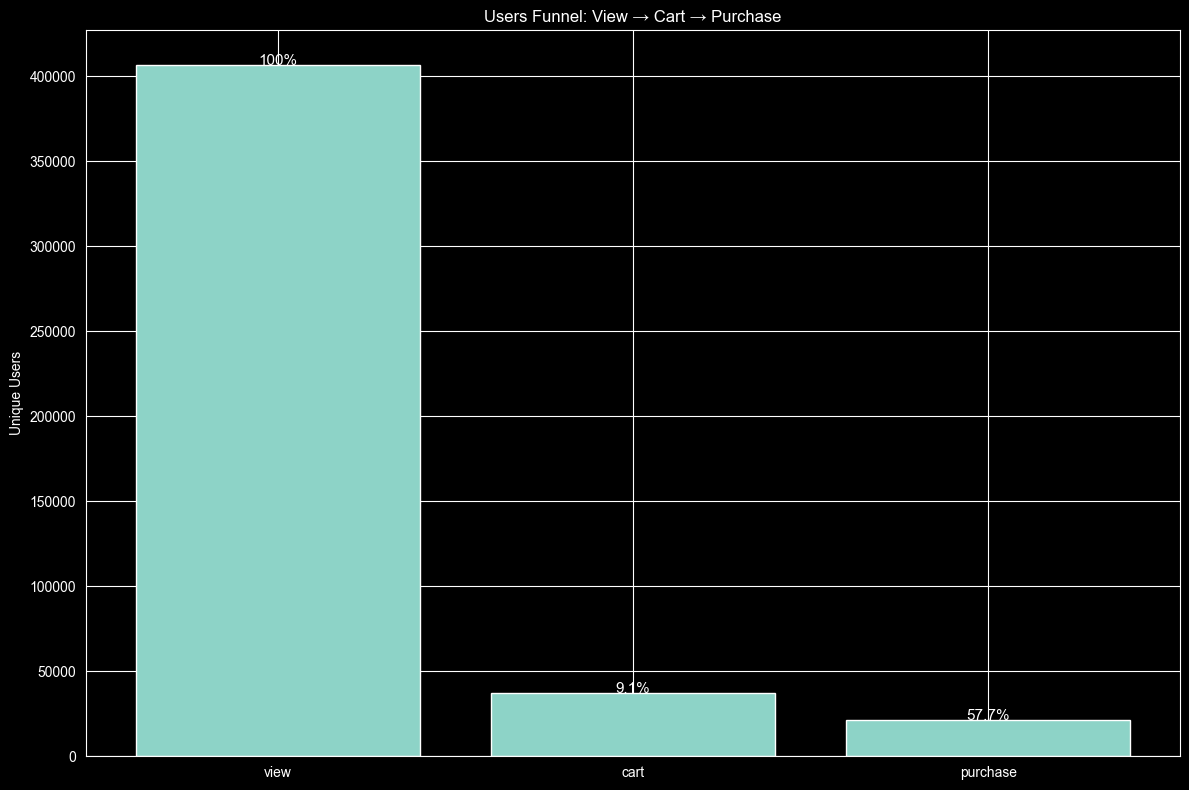

In [15]:
order = ['view', 'cart', 'purchase']
funnel_counts = funnel[order].sum()
view_to_cart = funnel_counts['cart'] / funnel_counts['view'] * 100
cart_to_purchase = funnel_counts['purchase'] / funnel_counts['cart'] * 100

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(funnel_counts.index, funnel_counts.values)

ax.set_title('Users Funnel: View → Cart → Purchase')
ax.set_ylabel('Unique Users')

labels = [
    '100%',
    f'{view_to_cart:.1f}%',
    f'{cart_to_purchase:.1f}%'
]

for bar, label in zip(bars, labels):
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height() + 100,
        label,
        ha='center',
        fontsize=11)

plt.tight_layout()
plt.show()

It is clear that the main issue in the sales funnel is not customers’ purchasing power, as purchases account for 57.7% of all customers who have added a product to their basket.

Key hypotheses:
* the problem lies with unattractive products and marketing: customers rarely add products to their basket and stop at the browsing stage.
* I would review how the product is presented to the customer: the name, description, presentation and layout.
* There may be an issue with the price; it is likely too high.
* Interface issues: buttons are hard to see, and the mobile UX is poor.
* Users are casual and are not looking for the right product.
* Lack of trust in the shop: there are no reviews.


# **Cohort analysis (Retention).**

### We want to check what percentage returns the following week. Which cohort has the highest retention rate.

without `week` we would have had to work with exact timestamps and users who arrived on the same day but at different times would have ended up in different groups


In [16]:
df['week'] = df['event_time'].dt.to_period('W').apply(lambda x: x.start_time)

C:\Users\chern\AppData\Local\Temp\ipykernel_28400\3885214351.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['event_time'].dt.to_period('W').apply(lambda x: x.start_time)


In [17]:
cohort_df = df.groupby('user_id')['week'].min().reset_index()
cohort_df.columns = ['user_id', 'cohort_week']

df = df.merge(cohort_df, on='user_id')

df['period'] = ((df['week'] - df['cohort_week']).dt.days / 7).astype(int)

cohort = df.groupby(['cohort_week', 'period'])['user_id'].nunique().unstack(fill_value=0)

cohort_pct = cohort.divide(cohort[0], axis=0).round(2)

cohort_df - identifies the first week for each user - their cohort.

The `merge` function is needed to compare the current week with the first week

Key concept of period = “the number of weeks that have passed since the user first arrived”

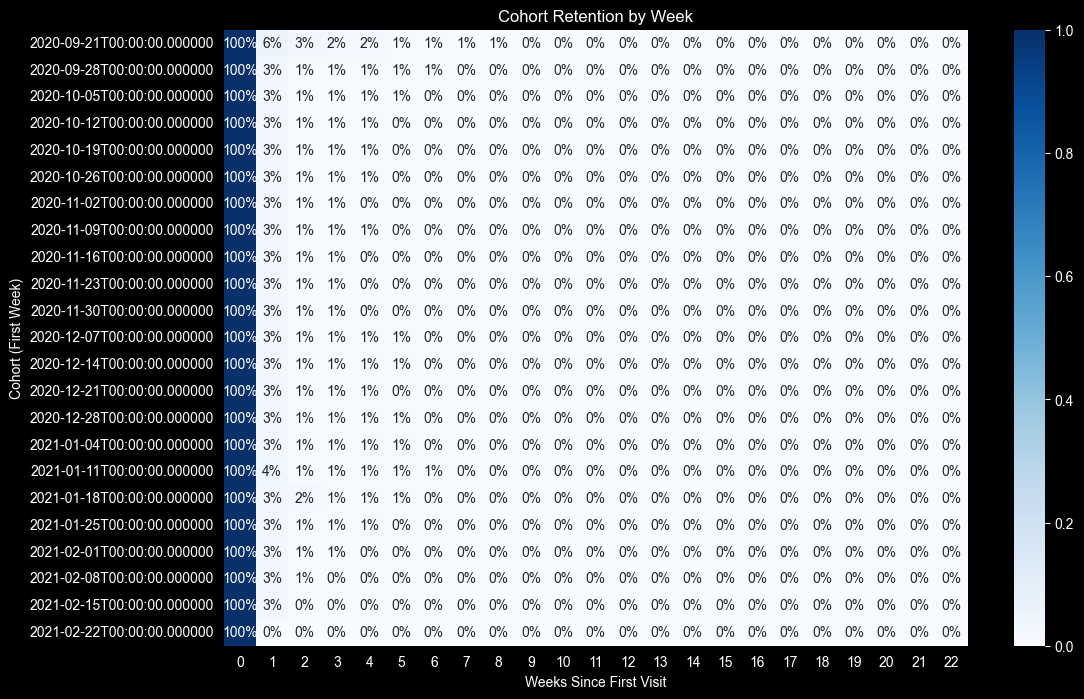

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(cohort_pct, annot=True, fmt='.0%', cmap='Blues')

plt.title('Cohort Retention by Week')
plt.ylabel('Cohort (First Week)')
plt.xlabel('Weeks Since First Visit')

plt.show()

User retention is extremely low: cohort analysis shows a return rate of around 0% as early as W4. In the first week alone, only ~3–6% of users return, after which activity drops off almost entirely. This indicates a lack of motivation to revisit the platform and a lack of long-term value

# Category Analysis

### **Which product categories have the best conversion rate from view to purchase?**

**_Exploratory step_**

In [19]:
print(df['category_code'].unique().tolist())

['electronics.clocks', 'unknown', 'electronics.audio.acoustic', 'computers.peripherals.printer', 'computers.components.videocards', 'electronics.telephone', 'electronics.audio.headphone', 'electronics.audio.microphone', 'computers.components.power_supply', 'computers.peripherals.wifi', 'construction.tools.light', 'computers.components.sound_card', 'stationery.cartrige', 'appliances.kitchen.microwave', 'computers.components.hdd', 'computers.components.motherboard', 'appliances.environment.vacuum', 'electronics.video.tv', 'computers.peripherals.mouse', 'electronics.tablet', 'auto.accessories.player', 'appliances.steam_cleaner', 'appliances.kitchen.coffee_machine', 'appliances.kitchen.juicer', 'auto.accessories.alarm', 'electronics.video.projector', 'computers.components.cpu', 'computers.peripherals.camera', 'appliances.kitchen.mixer', 'computers.notebook', 'computers.peripherals.monitor', 'auto.accessories.immobilizer', 'appliances.kitchen.kettle', 'stationery.paper', 'construction.tools

In [20]:
df['category_top'] = df['category_code'].apply(lambda x: x.split('.')[0] if x != 'unknown' else 'unknown')
print(df['category_top'].value_counts())

category_top
computers       316660
unknown         236001
electronics     170949
stationery       42948
appliances       41047
auto             35408
construction     31035
furniture         3364
country_yard      3137
accessories       2075
medicine           712
kids               372
jewelry            254
sport              232
apparel            118
Name: count, dtype: int64


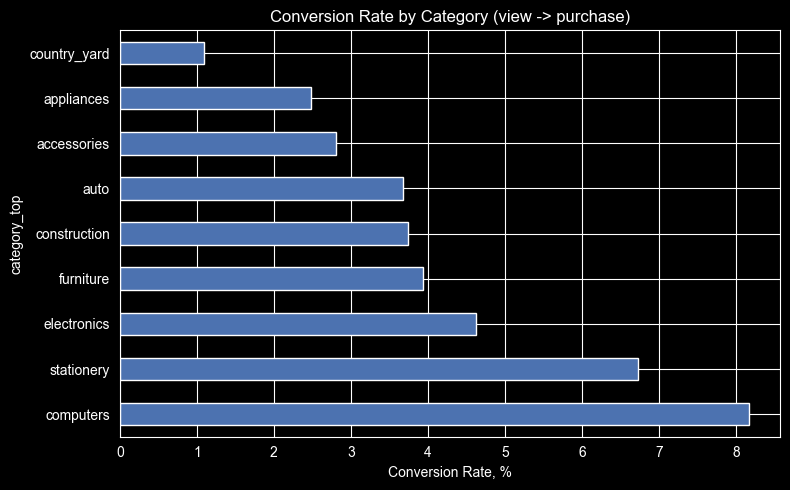

In [21]:
cat_funnel = df.groupby(['category_top', 'event_type'])['user_id'].nunique().unstack(fill_value=0)
cat_funnel['conversion'] = (cat_funnel['purchase'] / cat_funnel['view'] * 100).round(2)

cat_funnel_clean = cat_funnel[
    (cat_funnel.index != 'unknown') &
    (cat_funnel['view'] > 500)
].sort_values(by='conversion', ascending=False)

cat_funnel_clean['conversion'].plot(kind='barh', figsize=(8, 5), color='#4C72B0')
plt.title('Conversion Rate by Category (view -> purchase)')
plt.xlabel('Conversion Rate, %')
plt.tight_layout()
plt.show()

The ‘computers’ (8.2%) and ‘stationery’ (6.5%) categories show the highest conversion rates from views to purchases. It is likely that users arrive with a specific intention. The ‘country_yard’ and ‘appliances’ categories convert the least well – it is possible that customers are comparing prices with competitors and leaving to shop elsewhere, or are postponing their purchase decisions in the hope of lower prices. Recommendations: focus retargeting and increase reminders for categories with lower conversion rates.

# Overall conclusion and insight

I analysed three metrics: the funnel, retention, and the view-to-purchase conversion rate by category. There is an issue at the top of the view-to-cart funnel, as only 9% of users progress from viewing a product to adding it to their basket – this is a key bottleneck. Cohort retention analysis shows that by the fourth week, the return rate is already close to zero, and this figure does not increase throughout the entire period. In the first week, only 3–6% of users returned, indicating low motivation and engagement with the idea of purchasing a product. A category-based conversion analysis showed that two types of products dominate the categories: computers (8.2%) and stationery (6.5%), whilst the remaining categories lag significantly behind. I have two hypotheses:
1. Regarding stationery – users already know what they want and come looking for a specific item. Seasonality may also play a role here; for example, at the start of the academic term, demand for this category will be significantly higher than during the middle of the term. Additionally, we need to check for seasonality and, possibly, user (buyer) categories.
2. Regarding computers: a computer, like any other electronic device, is the sort of product people do not return to buy every day; or, if the product is expensive, they wait for price drops or promotions. Otherwise, users may switch to competitors – this may be partly indicated by low user retention.

Taken together, this all points to a weak conversion of interest into intent and low user retention. I cannot rule out issues with the interface or technical problems. Nevertheless, the situation at the bottom of the funnel is positive: 57.7% of users purchase the product they previously added to their basket, meaning there are no issues in this area, as the metric is performing well.